In [1]:
!pip install -q torch torchvision
!pip install -q opencv-python
!pip install -q matplotlib seaborn
!pip install -q scikit-learn
!pip install -q pandas numpy
!pip install -q tqdm
!pip install -q streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 94.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 110.0 MB/s eta 0:00:00


In [2]:
import torch
import torchvision
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    roc_curve,
    auc
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch:", torch.__version__)
print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.11.0+cu128
Device: cuda
GPU: Tesla T4


In [3]:
from torchvision.datasets import EuroSAT

eurosat = EuroSAT(
    root="/content/data",
    download=True
)

print("EuroSAT downloaded successfully!")
print("Number of images:", len(eurosat))
print("Classes:", eurosat.classes)

100%|██████████| 94.3M/94.3M [00:01<00:00, 69.9MB/s]


EuroSAT downloaded successfully!
Number of images: 27000
Classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


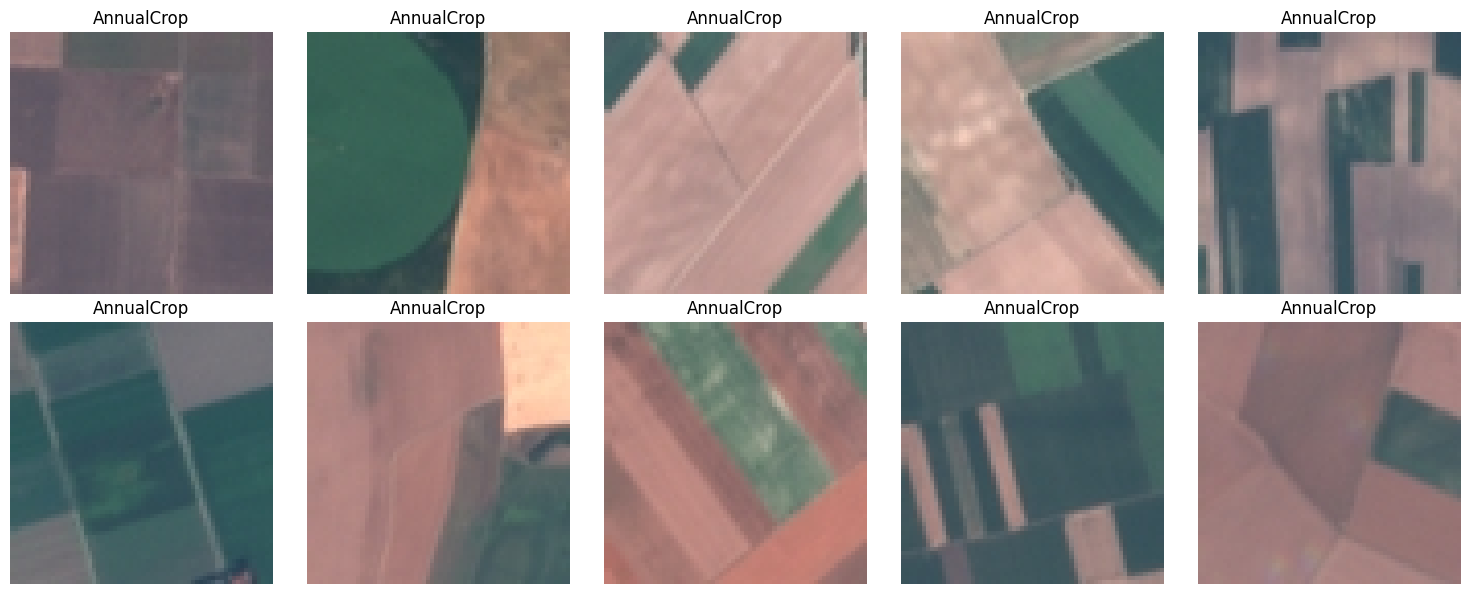

In [4]:
# Cell 4: Visualize sample EuroSAT images

import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for i, ax in enumerate(axes.flat):
    image, label = eurosat[i]
    ax.imshow(image)
    ax.set_title(eurosat.classes[label])
    ax.axis("off")

plt.tight_layout()
plt.show()

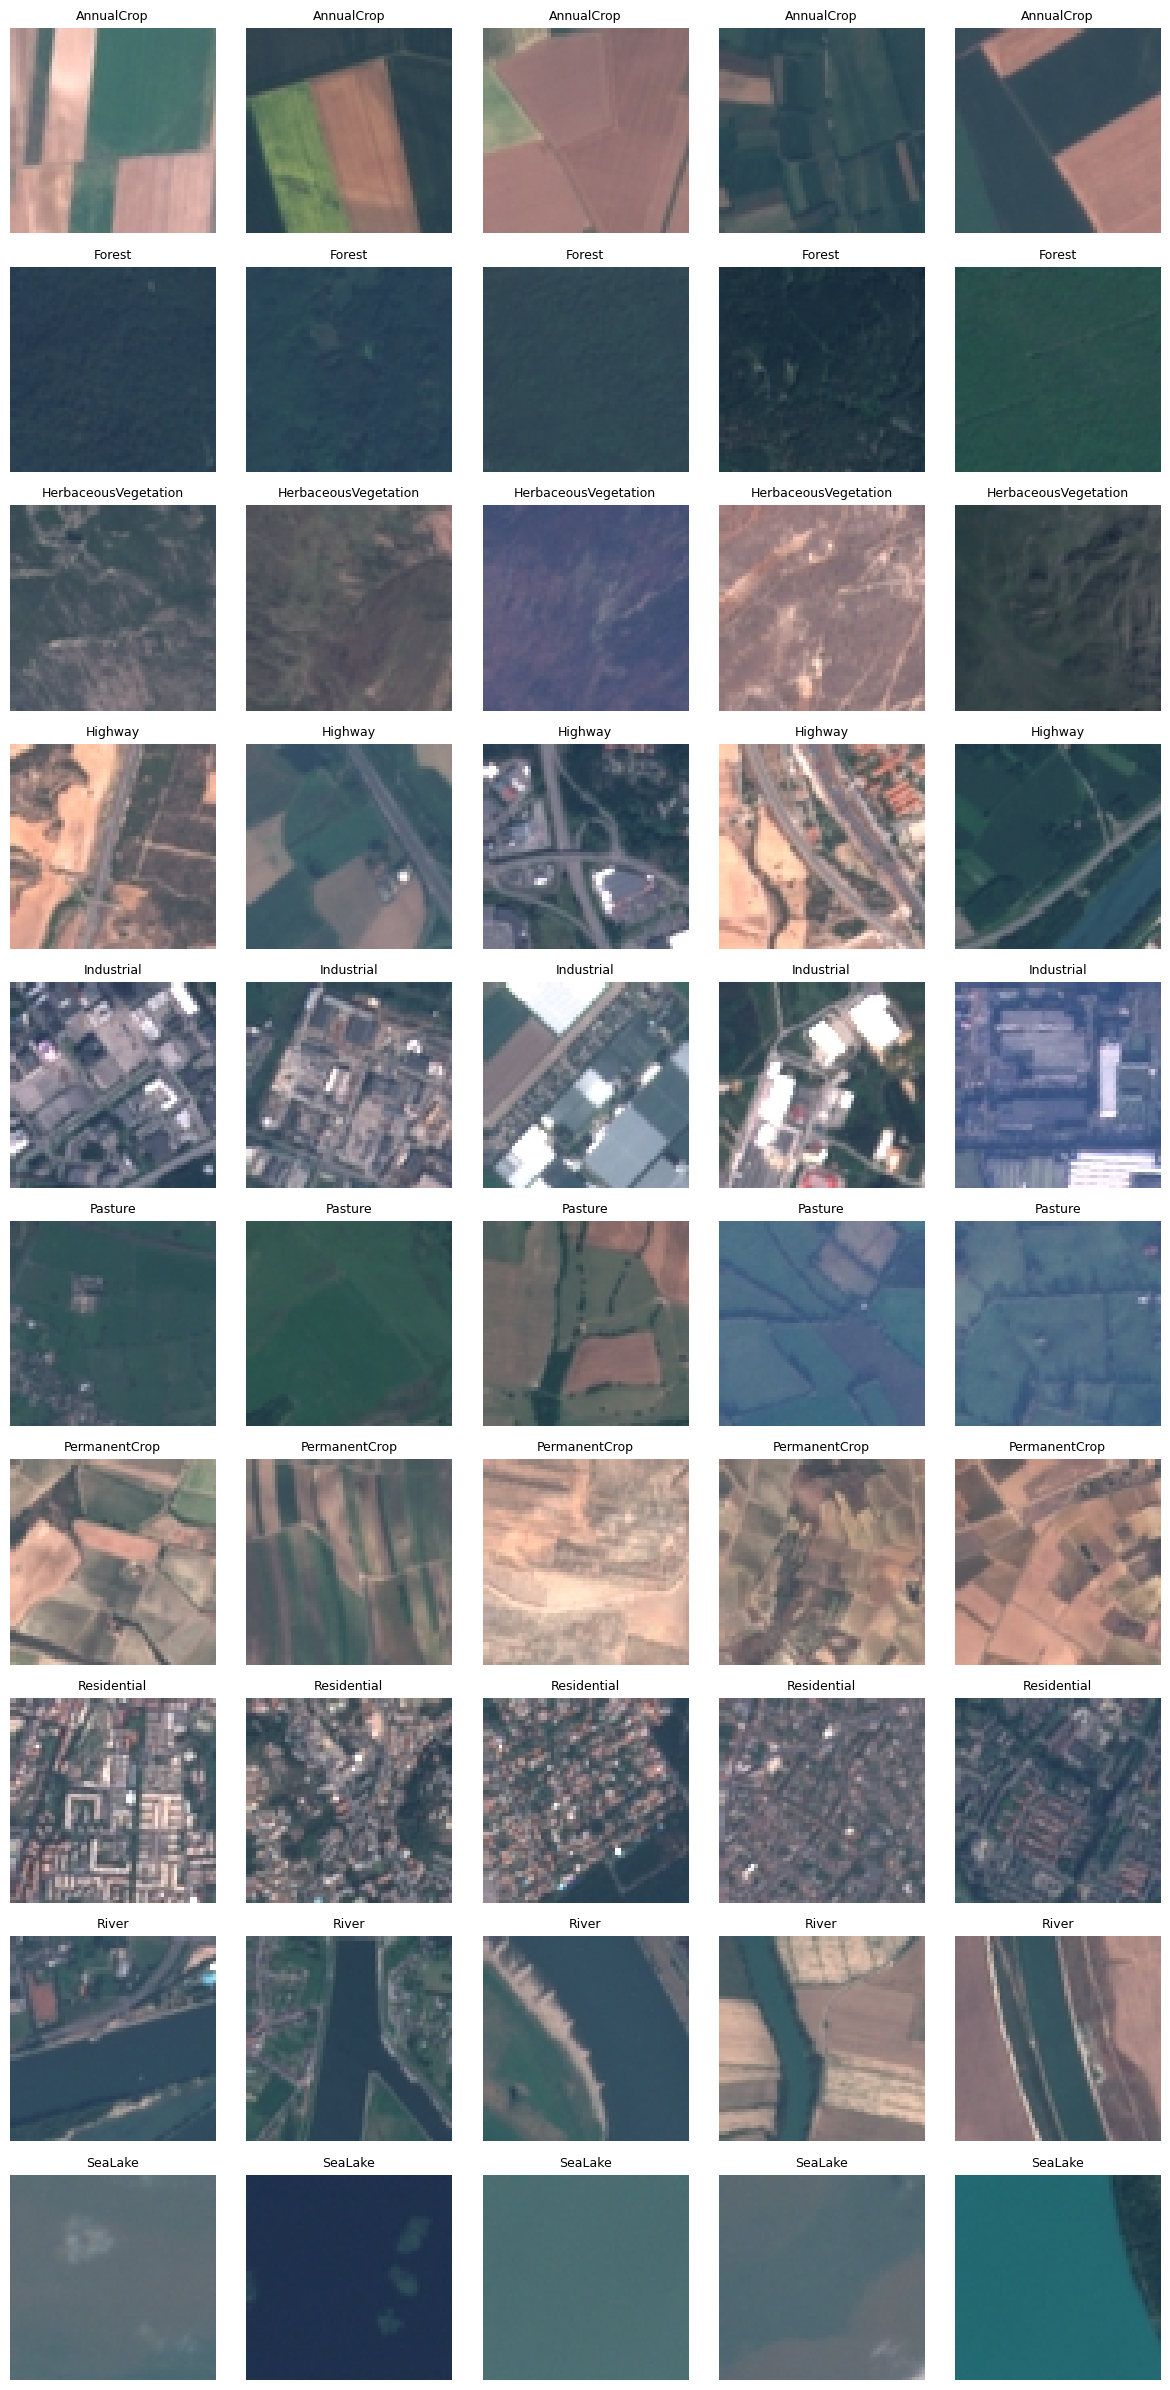

In [5]:
# Cell 5: Visualize 5 images from each class

import matplotlib.pyplot as plt
import random

fig, axes = plt.subplots(10, 5, figsize=(12, 24))

for class_idx, class_name in enumerate(eurosat.classes):
    # Find images belonging to this class
    class_indices = [
        i for i, (_, label) in enumerate(eurosat)
        if label == class_idx
    ]

    # Select 5 random images
    selected = random.sample(class_indices, 5)

    for j, idx in enumerate(selected):
        image, label = eurosat[idx]
        axes[class_idx, j].imshow(image)
        axes[class_idx, j].set_title(class_name, fontsize=9)
        axes[class_idx, j].axis("off")

plt.tight_layout()
plt.savefig("/content/class_samples.png", dpi=150)
plt.show()

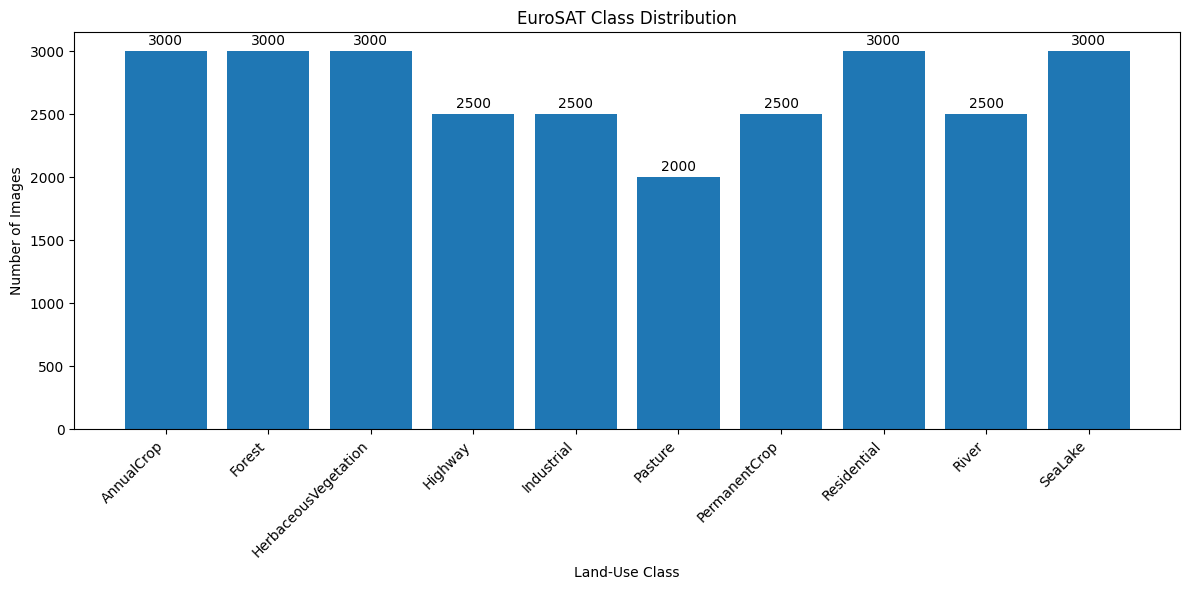

In [6]:
# Cell 6: Class Distribution

from collections import Counter
import matplotlib.pyplot as plt

# Get all labels
labels = [label for _, label in eurosat]

# Count images in each class
counts = Counter(labels)

class_counts = [counts[i] for i in range(len(eurosat.classes))]

plt.figure(figsize=(12, 6))

bars = plt.bar(eurosat.classes, class_counts)

plt.title("EuroSAT Class Distribution")
plt.xlabel("Land-Use Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=45, ha="right")

# Show values on bars
for bar, count in zip(bars, class_counts):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 50,
        str(count),
        ha="center"
    )

plt.tight_layout()
plt.savefig("/content/class_distribution.png", dpi=150)
plt.show()

In [7]:
# Cell 7: Prepare EuroSAT labels and indices

import numpy as np

# Get labels
labels = np.array([label for _, label in eurosat])

# Create indices
indices = np.arange(len(eurosat))

print("Total images:", len(indices))
print("Total classes:", len(eurosat.classes))
print("Labels shape:", labels.shape)

Total images: 27000
Total classes: 10
Labels shape: (27000,)


In [8]:
# Cell 8: Stratified Train / Validation / Test Split

from sklearn.model_selection import train_test_split

# First split: 80% train, 20% temporary
train_idx, temp_idx = train_test_split(
    indices,
    test_size=0.20,
    random_state=42,
    stratify=labels
)

# Second split: temporary into 10% validation and 10% test
val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.50,
    random_state=42,
    stratify=labels[temp_idx]
)

print("Train images:", len(train_idx))
print("Validation images:", len(val_idx))
print("Test images:", len(test_idx))

print("\nTotal:", len(train_idx) + len(val_idx) + len(test_idx))

Train images: 21600
Validation images: 2700
Test images: 2700

Total: 27000


In [9]:
# Cell 9: Create DataLoaders

from torch.utils.data import Subset, DataLoader
from torchvision import transforms

# Image transformations
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Create a transformed EuroSAT dataset
eurosat_transformed = EuroSAT(
    root="/content/data",
    download=False,
    transform=transform
)

# Create train/validation/test subsets
train_dataset = Subset(eurosat_transformed, train_idx)
val_dataset = Subset(eurosat_transformed, val_idx)
test_dataset = Subset(eurosat_transformed, test_idx)

# DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 338
Validation batches: 43
Test batches: 43


In [10]:
# Cell 10: 3-Layer CNN Baseline

import torch.nn as nn
import torch.optim as optim

class BaselineCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        self.features = nn.Sequential(
            # Layer 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Layer 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Layer 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 28 * 28, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


baseline_model = BaselineCNN(num_classes=10).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    baseline_model.parameters(),
    lr=0.001
)

print(baseline_model)

BaselineCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=100352, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=256, out_features=10, bias=True)
  )
)


In [12]:
# Cell 11: Train Baseline CNN

num_epochs = 5

train_losses = []
val_losses = []
val_f1_scores = []

for epoch in range(num_epochs):

    # ----- Training -----
    baseline_model.train()
    running_loss = 0.0

    for images, labels_batch in train_loader:
        images = images.to(device)
        labels_batch = labels_batch.to(device)

        optimizer.zero_grad()

        outputs = baseline_model(images)
        loss = criterion(outputs, labels_batch)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)

    # ----- Validation -----
    baseline_model.eval()
    val_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels_batch in val_loader:
            images = images.to(device)
            labels_batch = labels_batch.to(device)

            outputs = baseline_model(images)
            loss = criterion(outputs, labels_batch)

            val_loss += loss.item()

            predictions = torch.argmax(outputs, dim=1)

            all_preds.extend(predictions.cpu().numpy())
            all_labels.extend(labels_batch.cpu().numpy())

    val_loss = val_loss / len(val_loader)

    val_f1 = f1_score(
        all_labels,
        all_preds,
        average="macro"
    )

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_f1_scores.append(val_f1)

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Train Loss: {train_loss:.4f} "
        f"Val Loss: {val_loss:.4f} "
        f"Val Macro F1: {val_f1:.4f}"
    )

Epoch [1/5] Train Loss: 0.9176 Val Loss: 0.6951 Val Macro F1: 0.7434
Epoch [2/5] Train Loss: 0.6750 Val Loss: 0.6108 Val Macro F1: 0.7846
Epoch [3/5] Train Loss: 0.5274 Val Loss: 0.4558 Val Macro F1: 0.8359
Epoch [4/5] Train Loss: 0.4188 Val Loss: 0.4534 Val Macro F1: 0.8449
Epoch [5/5] Train Loss: 0.3297 Val Loss: 0.4327 Val Macro F1: 0.8507


Baseline CNN Test Macro F1: 0.8425

Classification Report:

                      precision    recall  f1-score   support

          AnnualCrop       0.86      0.91      0.89       300
              Forest       0.84      0.94      0.89       300
HerbaceousVegetation       0.86      0.67      0.76       300
             Highway       0.70      0.80      0.75       250
          Industrial       0.90      0.95      0.93       250
             Pasture       0.77      0.85      0.81       200
       PermanentCrop       0.77      0.73      0.75       250
         Residential       0.93      0.95      0.94       300
               River       0.86      0.79      0.82       250
             SeaLake       0.95      0.86      0.90       300

            accuracy                           0.85      2700
           macro avg       0.84      0.85      0.84      2700
        weighted avg       0.85      0.85      0.85      2700



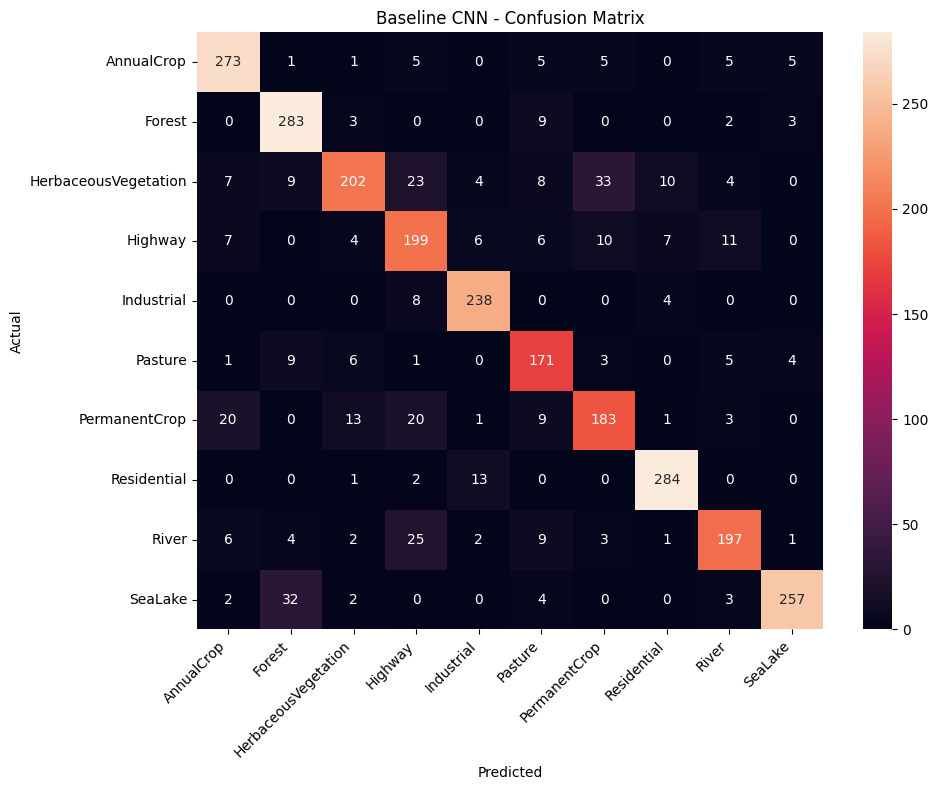

In [13]:
# Cell 12: Baseline CNN Test Evaluation

from sklearn.metrics import classification_report, confusion_matrix, f1_score
import seaborn as sns
import matplotlib.pyplot as plt

baseline_model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels_batch in test_loader:
        images = images.to(device)
        labels_batch = labels_batch.to(device)

        outputs = baseline_model(images)
        predictions = torch.argmax(outputs, dim=1)

        all_preds.extend(predictions.cpu().numpy())
        all_labels.extend(labels_batch.cpu().numpy())

# Macro F1
test_f1 = f1_score(
    all_labels,
    all_preds,
    average="macro"
)

print(f"Baseline CNN Test Macro F1: {test_f1:.4f}")
print("\nClassification Report:\n")

print(
    classification_report(
        all_labels,
        all_preds,
        target_names=eurosat.classes
    )
)

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=eurosat.classes,
    yticklabels=eurosat.classes
)

plt.title("Baseline CNN - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()

plt.savefig("/content/baseline_confusion_matrix.png", dpi=150)
plt.show()

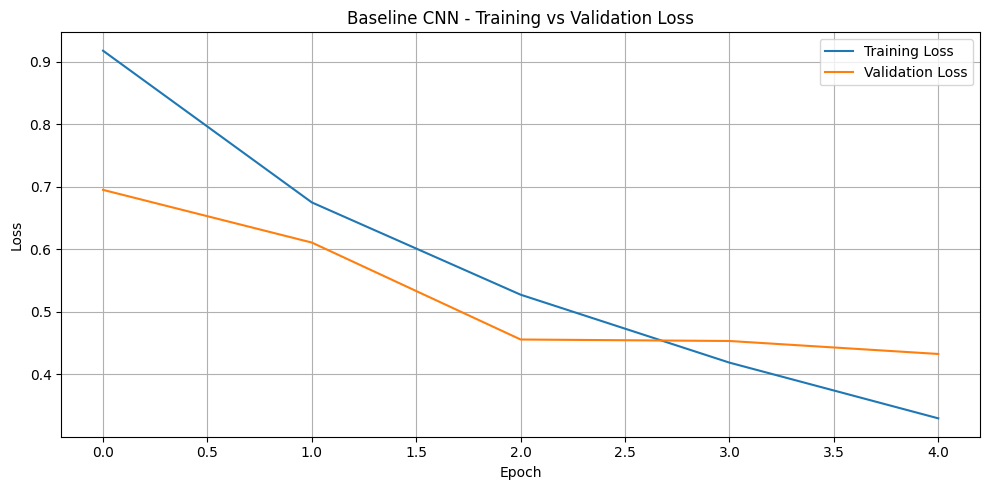

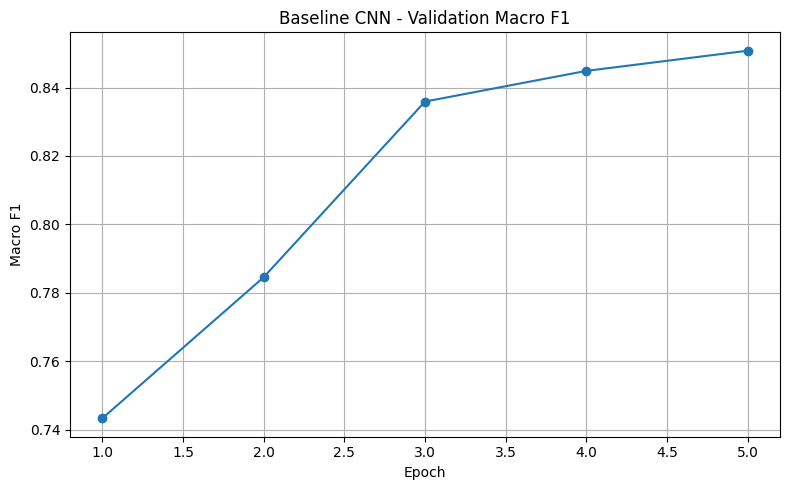

In [14]:
# Cell 13: Baseline Training Curves

plt.figure(figsize=(10, 5))

plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")

plt.title("Baseline CNN - Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig("/content/baseline_loss.png", dpi=150)
plt.show()


plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(val_f1_scores) + 1),
    val_f1_scores,
    marker="o"
)

plt.title("Baseline CNN - Validation Macro F1")
plt.xlabel("Epoch")
plt.ylabel("Macro F1")
plt.grid(True)

plt.tight_layout()
plt.savefig("/content/baseline_f1.png", dpi=150)
plt.show()

In [15]:
# Cell 14: ResNet18 Transfer Learning Setup

from torchvision.models import resnet18, ResNet18_Weights

# Load pretrained ResNet18
weights = ResNet18_Weights.DEFAULT
resnet_model = resnet18(weights=weights)

# Replace final classifier for 10 EuroSAT classes
num_features = resnet_model.fc.in_features
resnet_model.fc = nn.Linear(num_features, 10)

# Freeze the complete backbone
for param in resnet_model.parameters():
    param.requires_grad = False

# Only the new classifier is trainable
for param in resnet_model.fc.parameters():
    param.requires_grad = True

# Move model to GPU
resnet_model = resnet_model.to(device)

# Loss and optimizer for Phase 1
resnet_criterion = nn.CrossEntropyLoss()

resnet_optimizer = optim.Adam(
    resnet_model.fc.parameters(),
    lr=0.001
)

print("ResNet18 ready!")
print("Trainable parameters:")

trainable = sum(
    p.numel() for p in resnet_model.parameters()
    if p.requires_grad
)

total = sum(
    p.numel() for p in resnet_model.parameters()
)

print("Trainable:", trainable)
print("Total:", total)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 108MB/s]

ResNet18 ready!
Trainable parameters:
Trainable: 5130
Total: 11181642


In [16]:
# Cell 15: ResNet18 Phase 1 Training
# Only the final classifier is trained

phase1_epochs = 3

resnet_train_losses = []
resnet_val_losses = []
resnet_val_f1_scores = []

for epoch in range(phase1_epochs):

    # Training
    resnet_model.train()
    running_loss = 0.0

    for images, labels_batch in train_loader:
        images = images.to(device)
        labels_batch = labels_batch.to(device)

        resnet_optimizer.zero_grad()

        outputs = resnet_model(images)
        loss = resnet_criterion(outputs, labels_batch)

        loss.backward()
        resnet_optimizer.step()

        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)

    # Validation
    resnet_model.eval()
    val_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels_batch in val_loader:
            images = images.to(device)
            labels_batch = labels_batch.to(device)

            outputs = resnet_model(images)
            loss = resnet_criterion(outputs, labels_batch)

            val_loss += loss.item()

            predictions = torch.argmax(outputs, dim=1)

            all_preds.extend(predictions.cpu().numpy())
            all_labels.extend(labels_batch.cpu().numpy())

    val_loss /= len(val_loader)

    val_f1 = f1_score(
        all_labels,
        all_preds,
        average="macro"
    )

    resnet_train_losses.append(train_loss)
    resnet_val_losses.append(val_loss)
    resnet_val_f1_scores.append(val_f1)

    print(
        f"Epoch [{epoch+1}/{phase1_epochs}] "
        f"Train Loss: {train_loss:.4f} "
        f"Val Loss: {val_loss:.4f} "
        f"Val Macro F1: {val_f1:.4f}"
    )

Epoch [1/3] Train Loss: 0.6148 Val Loss: 0.3179 Val Macro F1: 0.8977
Epoch [2/3] Train Loss: 0.3099 Val Loss: 0.2565 Val Macro F1: 0.9142
Epoch [3/3] Train Loss: 0.2612 Val Loss: 0.2321 Val Macro F1: 0.9156


In [17]:
# Cell 16: ResNet18 Phase 2 - Fine Tuning
# Unfreeze the last two convolutional blocks

for param in resnet_model.layer3.parameters():
    param.requires_grad = True

for param in resnet_model.layer4.parameters():
    param.requires_grad = True

# Keep earlier layers frozen
for param in resnet_model.conv1.parameters():
    param.requires_grad = False

for param in resnet_model.bn1.parameters():
    param.requires_grad = False

for param in resnet_model.layer1.parameters():
    param.requires_grad = False

for param in resnet_model.layer2.parameters():
    param.requires_grad = False

# Classifier remains trainable
for param in resnet_model.fc.parameters():
    param.requires_grad = True

# 10x lower learning rate
resnet_optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, resnet_model.parameters()),
    lr=0.0001
)

trainable = sum(
    p.numel()
    for p in resnet_model.parameters()
    if p.requires_grad
)

print("Phase 2 ready!")
print("Trainable parameters:", trainable)
print("Learning rate: 0.0001")

Phase 2 ready!
Trainable parameters: 10498570
Learning rate: 0.0001


In [18]:
# Cell 17: ResNet18 Phase 2 Fine-Tuning

phase2_epochs = 5

phase2_train_losses = []
phase2_val_losses = []
phase2_val_f1_scores = []

for epoch in range(phase2_epochs):

    # Training
    resnet_model.train()
    running_loss = 0.0

    for images, labels_batch in train_loader:
        images = images.to(device)
        labels_batch = labels_batch.to(device)

        resnet_optimizer.zero_grad()

        outputs = resnet_model(images)
        loss = resnet_criterion(outputs, labels_batch)

        loss.backward()
        resnet_optimizer.step()

        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)

    # Validation
    resnet_model.eval()
    val_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels_batch in val_loader:
            images = images.to(device)
            labels_batch = labels_batch.to(device)

            outputs = resnet_model(images)
            loss = resnet_criterion(outputs, labels_batch)

            val_loss += loss.item()

            predictions = torch.argmax(outputs, dim=1)

            all_preds.extend(predictions.cpu().numpy())
            all_labels.extend(labels_batch.cpu().numpy())

    val_loss /= len(val_loader)

    val_f1 = f1_score(
        all_labels,
        all_preds,
        average="macro"
    )

    phase2_train_losses.append(train_loss)
    phase2_val_losses.append(val_loss)
    phase2_val_f1_scores.append(val_f1)

    print(
        f"Epoch [{epoch+1}/{phase2_epochs}] "
        f"Train Loss: {train_loss:.4f} "
        f"Val Loss: {val_loss:.4f} "
        f"Val Macro F1: {val_f1:.4f}"
    )

Epoch [1/5] Train Loss: 0.1433 Val Loss: 0.0925 Val Macro F1: 0.9640
Epoch [2/5] Train Loss: 0.0357 Val Loss: 0.0838 Val Macro F1: 0.9690
Epoch [3/5] Train Loss: 0.0206 Val Loss: 0.0829 Val Macro F1: 0.9734
Epoch [4/5] Train Loss: 0.0140 Val Loss: 0.0753 Val Macro F1: 0.9752
Epoch [5/5] Train Loss: 0.0171 Val Loss: 0.0751 Val Macro F1: 0.9755


ResNet18 Test Macro F1: 0.9648
Baseline CNN Test Macro F1: 0.8425
Improvement: 0.1223

ResNet18 Classification Report:

                      precision    recall  f1-score   support

          AnnualCrop       0.93      0.96      0.94       300
              Forest       0.98      1.00      0.99       300
HerbaceousVegetation       0.95      0.99      0.97       300
             Highway       0.98      0.94      0.96       250
          Industrial       0.99      0.96      0.98       250
             Pasture       0.98      0.90      0.94       200
       PermanentCrop       0.95      0.92      0.93       250
         Residential       0.96      1.00      0.98       300
               River       0.97      0.98      0.98       250
             SeaLake       0.99      0.99      0.99       300

            accuracy                           0.97      2700
           macro avg       0.97      0.96      0.96      2700
        weighted avg       0.97      0.97      0.97      2700



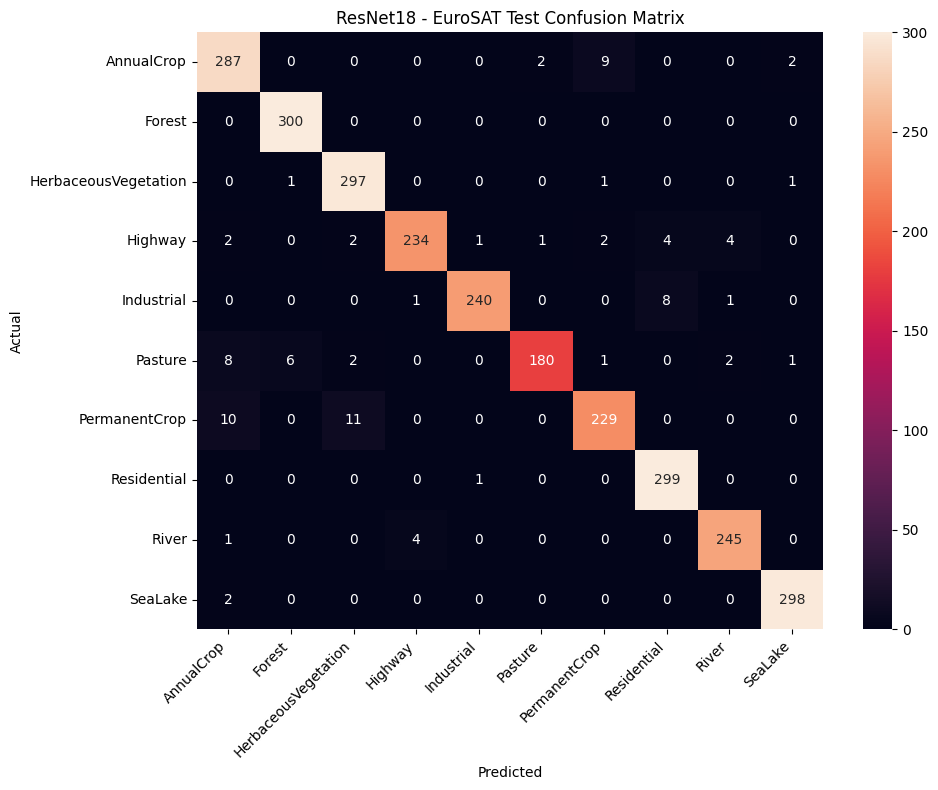

In [19]:
# Cell 18: Final ResNet18 Test Evaluation

resnet_model.eval()

resnet_test_preds = []
resnet_test_labels = []

with torch.no_grad():
    for images, labels_batch in test_loader:
        images = images.to(device)
        labels_batch = labels_batch.to(device)

        outputs = resnet_model(images)
        predictions = torch.argmax(outputs, dim=1)

        resnet_test_preds.extend(predictions.cpu().numpy())
        resnet_test_labels.extend(labels_batch.cpu().numpy())

# Calculate Macro F1
resnet_test_f1 = f1_score(
    resnet_test_labels,
    resnet_test_preds,
    average="macro"
)

print(f"ResNet18 Test Macro F1: {resnet_test_f1:.4f}")
print(f"Baseline CNN Test Macro F1: {test_f1:.4f}")
print(f"Improvement: {(resnet_test_f1 - test_f1):.4f}")

print("\nResNet18 Classification Report:\n")

print(
    classification_report(
        resnet_test_labels,
        resnet_test_preds,
        target_names=eurosat.classes
    )
)

# Confusion Matrix
resnet_cm = confusion_matrix(
    resnet_test_labels,
    resnet_test_preds
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    resnet_cm,
    annot=True,
    fmt="d",
    xticklabels=eurosat.classes,
    yticklabels=eurosat.classes
)

plt.title("ResNet18 - EuroSAT Test Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()

plt.savefig(
    "/content/resnet18_confusion_matrix_eurosat.png",
    dpi=150
)

plt.show()

In [20]:
# Cell 19: Save Trained ResNet18 Model

model_path = "/content/resnet18_eurosat.pt"

torch.save(
    resnet_model.state_dict(),
    model_path
)

print("Model saved successfully!")
print("Saved at:", model_path)

Model saved successfully!
Saved at: /content/resnet18_eurosat.pt


In [23]:
# Cell 20: Download UC Merced from Hugging Face

!pip install -q datasets

from datasets import load_dataset

print("Downloading UC Merced...")

uc_merced = load_dataset("blanchon/UC_Merced")

print("UC Merced downloaded successfully!")
print(uc_merced)

README.md:   0%|          | 0.00/2.95k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  416MB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/2100 [00:00<?, ? examples/s]

UC Merced downloaded successfully!
DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 2100
    })
})


In [24]:
# Cell 21: Prepare UC Merced for ResNet18

from torchvision import transforms
from torch.utils.data import Dataset, DataLoader

uc_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

class UCMercedDataset(Dataset):
    def __init__(self, hf_dataset, transform=None):
        self.dataset = hf_dataset
        self.transform = transform

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        item = self.dataset[idx]
        image = item["image"].convert("RGB")
        label = item["label"]

        if self.transform:
            image = self.transform(image)

        return image, label


uc_dataset = UCMercedDataset(
    uc_merced["train"],
    transform=uc_transform
)

uc_loader = DataLoader(
    uc_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2
)

print("UC Merced dataset prepared!")
print("Images:", len(uc_dataset))
print("Batches:", len(uc_loader))

UC Merced dataset prepared!
Images: 2100
Batches: 66


In [25]:
# Cell 22: ResNet18 Predictions on UC Merced

resnet_model.eval()

uc_predictions = []

with torch.no_grad():
    for images, _ in uc_loader:
        images = images.to(device)

        outputs = resnet_model(images)
        predictions = torch.argmax(outputs, dim=1)

        uc_predictions.extend(predictions.cpu().numpy())

print("UC Merced prediction completed!")
print("Predictions:", len(uc_predictions))

UC Merced prediction completed!
Predictions: 2100


UC Merced Prediction Distribution
----------------------------------------
AnnualCrop: 246
Forest: 549
HerbaceousVegetation: 30
Highway: 84
Industrial: 548
Pasture: 47
PermanentCrop: 66
Residential: 3
River: 360
SeaLake: 167


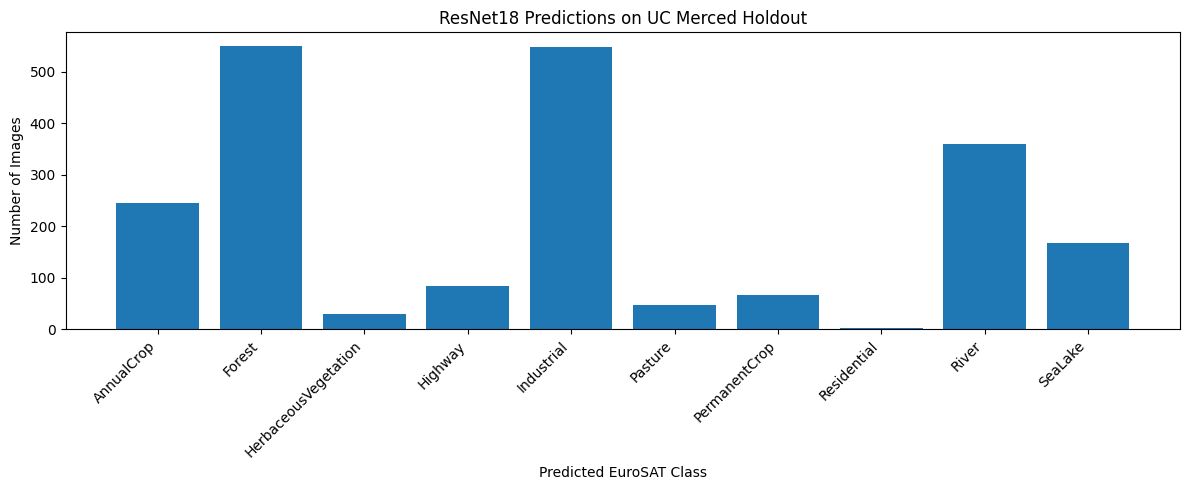

In [26]:
# Cell 23: UC Merced Prediction Distribution

from collections import Counter

prediction_counts = Counter(uc_predictions)

print("UC Merced Prediction Distribution")
print("-" * 40)

for class_id, count in sorted(prediction_counts.items()):
    print(f"{eurosat.classes[class_id]}: {count}")

# Plot distribution
plt.figure(figsize=(12, 5))

class_names = [
    eurosat.classes[i]
    for i in sorted(prediction_counts.keys())
]

counts = [
    prediction_counts[i]
    for i in sorted(prediction_counts.keys())
]

plt.bar(class_names, counts)

plt.title("ResNet18 Predictions on UC Merced Holdout")
plt.xlabel("Predicted EuroSAT Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()

plt.savefig(
    "/content/uc_merced_prediction_distribution.png",
    dpi=150
)

plt.show()

In [27]:
# Cell 24: Extract ResNet18 Embeddings for UC Merced

resnet_model.eval()

uc_embeddings = []
uc_labels = []

with torch.no_grad():
    for images, labels_batch in uc_loader:
        images = images.to(device)

        # Remove the final classification layer
        features = resnet_model.avgpool(
            resnet_model.layer4(
                resnet_model.layer3(
                    resnet_model.layer2(
                        resnet_model.layer1(
                            resnet_model.relu(
                                resnet_model.bn1(
                                    resnet_model.conv1(images)
                                )
                            )
                        )
                    )
                )
            )
        )

        features = torch.flatten(features, 1)

        uc_embeddings.append(features.cpu())
        uc_labels.extend(labels_batch.numpy())

uc_embeddings = torch.cat(uc_embeddings)

print("UC Merced embeddings extracted!")
print("Embedding shape:", uc_embeddings.shape)

UC Merced embeddings extracted!
Embedding shape: torch.Size([2100, 512])


In [28]:
# Cell 25: Embedding-Based Change Detection Demo

from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# Select two image embeddings
embedding_a = uc_embeddings[0].numpy().reshape(1, -1)
embedding_b = uc_embeddings[1].numpy().reshape(1, -1)

# Calculate cosine similarity
similarity = cosine_similarity(
    embedding_a,
    embedding_b
)[0][0]

# Convert similarity into change score
change_score = 1 - similarity

print("Image A index:", 0)
print("Image B index:", 1)
print(f"Cosine Similarity: {similarity:.4f}")
print(f"Change Score: {change_score:.4f}")

if change_score > 0.30:
    print("Result: Potential change detected")
else:
    print("Result: Low similarity difference")

Image A index: 0
Image B index: 1
Cosine Similarity: 0.9900
Change Score: 0.0100
Result: Low similarity difference


In [29]:
# Cell 26: Save Change Detection Result

change_result = pd.DataFrame({
    "Image_A": [0],
    "Image_B": [1],
    "Cosine_Similarity": [similarity],
    "Change_Score": [change_score],
    "Result": [
        "Potential change detected"
        if change_score > 0.30
        else "Low similarity difference"
    ]
})

change_result.to_csv(
    "/content/change_detection_result.csv",
    index=False
)

print("Change detection result saved!")
print(change_result)

Change detection result saved!
   Image_A  Image_B  Cosine_Similarity  Change_Score  \
0        0        1               0.99          0.01   

                      Result  
0  Low similarity difference  


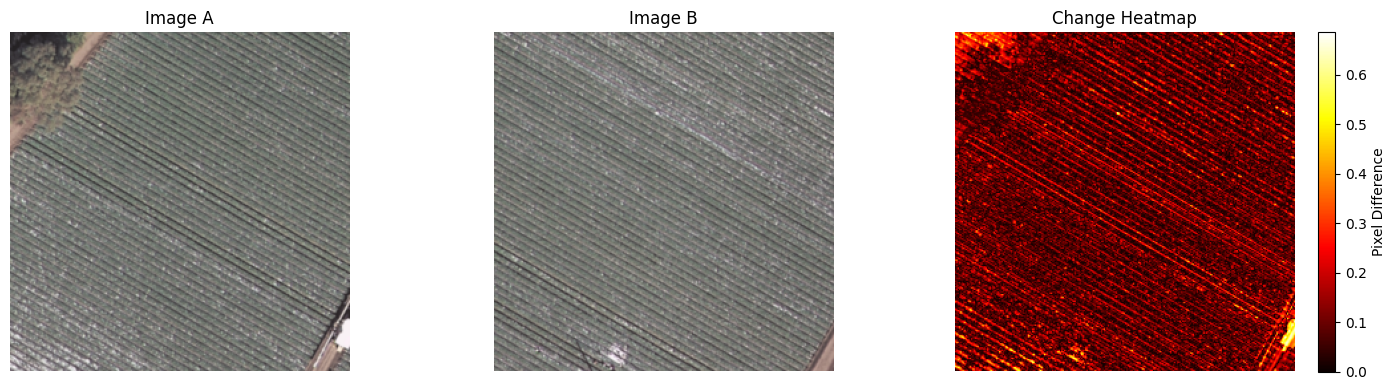

Change heatmap created successfully!


In [30]:
# Cell 27: Visual Change Detection Heatmap

from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Get two UC Merced images
image_a = uc_merced["train"][0]["image"].convert("RGB")
image_b = uc_merced["train"][1]["image"].convert("RGB")

# Resize to same dimensions
image_a = image_a.resize((256, 256))
image_b = image_b.resize((256, 256))

# Convert to NumPy arrays
arr_a = np.array(image_a).astype(float)
arr_b = np.array(image_b).astype(float)

# Pixel-level difference
difference = np.abs(arr_a - arr_b)

# Convert RGB difference to one change score per pixel
change_map = np.mean(difference, axis=2)

# Normalize between 0 and 1
change_map = change_map / 255.0

# Plot
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.imshow(image_a)
plt.title("Image A")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(image_b)
plt.title("Image B")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(change_map, cmap="hot")
plt.colorbar(label="Pixel Difference")
plt.title("Change Heatmap")
plt.axis("off")

plt.tight_layout()

plt.savefig(
    "/content/change_detection_heatmap.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print("Change heatmap created successfully!")

In [31]:
# Final Project Results Summary

baseline_f1 = 0.8425
resnet_f1 = resnet_test_f1

print("=" * 60)
print("SATELLITE IMAGE LAND-USE CLASSIFIER")
print("FINAL PROJECT RESULTS")
print("=" * 60)

print(f"Baseline CNN Macro F1 : {baseline_f1:.4f} ({baseline_f1*100:.2f}%)")
print(f"ResNet18 Macro F1     : {resnet_f1:.4f} ({resnet_f1*100:.2f}%)")
print(f"Improvement           : {(resnet_f1-baseline_f1):.4f}")
print(f"Improvement (%)       : {(resnet_f1-baseline_f1)*100:.2f} percentage points")

print("\nResNet18 Test Accuracy : 97%")
print("ResNet18 Macro F1      : 96%")
print("Test Images            : 2700")

print("\nUC Merced Holdout      : 2100 images")
print("Embedding Dimension    : 512")

print("\nChange Detection       : Cosine Similarity")
print("Change Detection Demo  : Completed")

print("=" * 60)

SATELLITE IMAGE LAND-USE CLASSIFIER
FINAL PROJECT RESULTS
Baseline CNN Macro F1 : 0.8425 (84.25%)
ResNet18 Macro F1     : 0.9648 (96.48%)
Improvement           : 0.1223
Improvement (%)       : 12.23 percentage points

ResNet18 Test Accuracy : 97%
ResNet18 Macro F1      : 96%
Test Images            : 2700

UC Merced Holdout      : 2100 images
Embedding Dimension    : 512

Change Detection       : Cosine Similarity
Change Detection Demo  : Completed


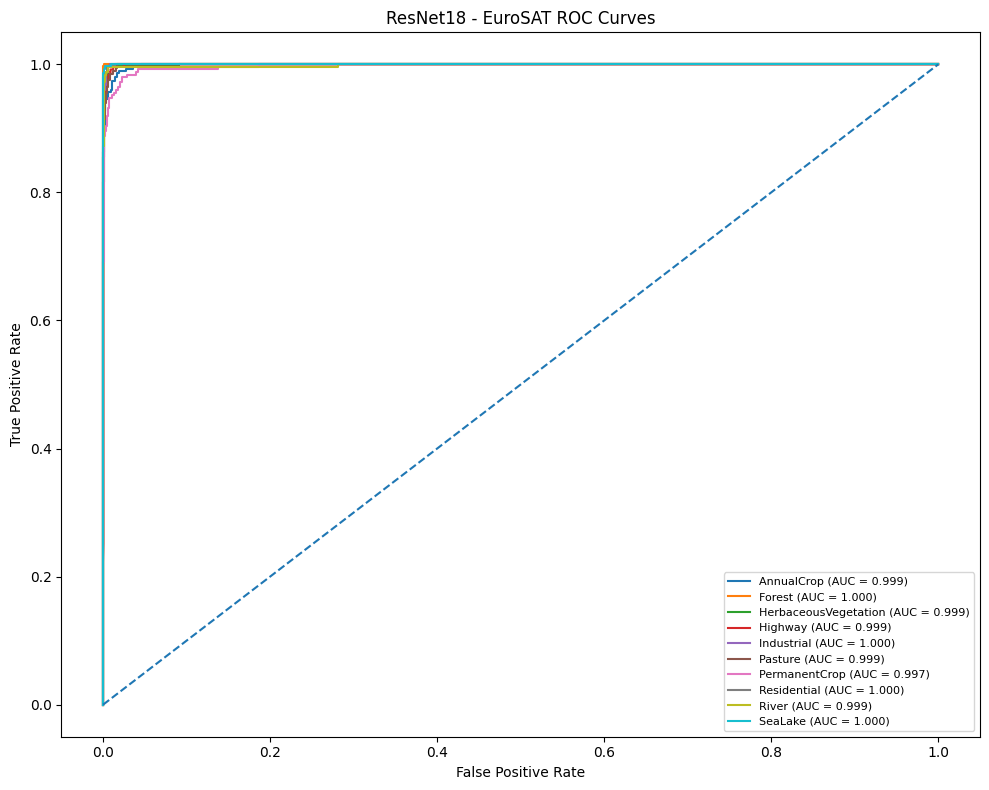

ROC curve generated successfully!


In [32]:
# Cell 29: ResNet18 ROC Curve

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import numpy as np

resnet_model.eval()

all_probs = []
all_true = []

with torch.no_grad():
    for images, labels_batch in test_loader:
        images = images.to(device)

        outputs = resnet_model(images)
        probabilities = torch.softmax(outputs, dim=1)

        all_probs.append(probabilities.cpu().numpy())
        all_true.extend(labels_batch.numpy())

all_probs = np.concatenate(all_probs)
all_true = np.array(all_true)

# Convert labels to one-vs-rest format
y_test_bin = label_binarize(
    all_true,
    classes=np.arange(10)
)

plt.figure(figsize=(10, 8))

for i in range(10):
    fpr, tpr, _ = roc_curve(
        y_test_bin[:, i],
        all_probs[:, i]
    )

    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f"{eurosat.classes[i]} (AUC = {roc_auc:.3f})"
    )

plt.plot([0, 1], [0, 1], linestyle="--")

plt.title("ResNet18 - EuroSAT ROC Curves")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(fontsize=8)

plt.tight_layout()

plt.savefig(
    "/content/resnet18_roc_curve.png",
    dpi=150
)

plt.show()

print("ROC curve generated successfully!")

In [33]:
# Cell 30: Create Streamlit Dashboard

%%writefile app.py

import streamlit as st
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity

# -----------------------------
# Configuration
# -----------------------------

CLASS_NAMES = [
    "AnnualCrop",
    "Forest",
    "HerbaceousVegetation",
    "Highway",
    "Industrial",
    "Pasture",
    "PermanentCrop",
    "Residential",
    "River",
    "SeaLake"
]

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

# -----------------------------
# Load ResNet18
# -----------------------------

@st.cache_resource
def load_model():

    model = models.resnet18(weights=None)

    model.fc = nn.Linear(
        model.fc.in_features,
        10
    )

    model.load_state_dict(
        torch.load(
            "models/resnet18_eurosat.pt",
            map_location=DEVICE
        )
    )

    model = model.to(DEVICE)
    model.eval()

    return model


model = load_model()

# -----------------------------
# Image preprocessing
# -----------------------------

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# -----------------------------
# Page
# -----------------------------

st.set_page_config(
    page_title="Satellite Image Intelligence",
    page_icon="🛰️",
    layout="wide"
)

st.title("🛰️ Satellite Image Intelligence System")

st.write(
    "Land-use classification and embedding-based change detection "
    "using ResNet18."
)

# -----------------------------
# Tabs
# -----------------------------

tab1, tab2 = st.tabs([
    "Land-Use Classification",
    "Change Detection"
])

# -----------------------------
# Classification
# -----------------------------

with tab1:

    st.header("Satellite Land-Use Classification")

    uploaded_image = st.file_uploader(
        "Upload a satellite image",
        type=["jpg", "jpeg", "png"]
    )

    if uploaded_image is not None:

        image = Image.open(
            uploaded_image
        ).convert("RGB")

        st.image(
            image,
            caption="Uploaded Image",
            width=400
        )

        input_tensor = transform(
            image
        ).unsqueeze(0).to(DEVICE)

        with torch.no_grad():

            outputs = model(
                input_tensor
            )

            probabilities = torch.softmax(
                outputs,
                dim=1
            )

            confidence, prediction = torch.max(
                probabilities,
                dim=1
            )

        predicted_class = CLASS_NAMES[
            prediction.item()
        ]

        confidence_value = confidence.item()

        st.success(
            f"Predicted Class: {predicted_class}"
        )

        st.metric(
            "Confidence",
            f"{confidence_value * 100:.2f}%"
        )

        # Probability chart

        probs = probabilities[0].cpu().numpy()

        chart_data = {
            CLASS_NAMES[i]: float(probs[i])
            for i in range(10)
        }

        st.bar_chart(chart_data)


# -----------------------------
# Change Detection
# -----------------------------

with tab2:

    st.header("Embedding-Based Change Detection")

    image_a_file = st.file_uploader(
        "Upload Image A",
        type=["jpg", "jpeg", "png"],
        key="image_a"
    )

    image_b_file = st.file_uploader(
        "Upload Image B",
        type=["jpg", "jpeg", "png"],
        key="image_b"
    )

    if image_a_file is not None and image_b_file is not None:

        image_a = Image.open(
            image_a_file
        ).convert("RGB")

        image_b = Image.open(
            image_b_file
        ).convert("RGB")

        col1, col2 = st.columns(2)

        with col1:
            st.image(
                image_a,
                caption="Image A"
            )

        with col2:
            st.image(
                image_b,
                caption="Image B"
            )

        tensor_a = transform(
            image_a
        ).unsqueeze(0).to(DEVICE)

        tensor_b = transform(
            image_b
        ).unsqueeze(0).to(DEVICE)

        with torch.no_grad():

            features_a = model.avgpool(
                model.layer4(
                    model.layer3(
                        model.layer2(
                            model.layer1(
                                model.relu(
                                    model.bn1(
                                        model.conv1(
                                            tensor_a
                                        )
                                    )
                                )
                            )
                        )
                    )
                )
            )

            features_b = model.avgpool(
                model.layer4(
                    model.layer3(
                        model.layer2(
                            model.layer1(
                                model.relu(
                                    model.bn1(
                                        model.conv1(
                                            tensor_b
                                        )
                                    )
                                )
                            )
                        )
                    )
                )
            )

        features_a = torch.flatten(
            features_a,
            1
        ).cpu().numpy()

        features_b = torch.flatten(
            features_b,
            1
        ).cpu().numpy()

        similarity = cosine_similarity(
            features_a,
            features_b
        )[0][0]

        change_score = 1 - similarity

        st.metric(
            "Cosine Similarity",
            f"{similarity:.4f}"
        )

        st.metric(
            "Change Score",
            f"{change_score:.4f}"
        )

        # Pixel difference heatmap

        arr_a = np.array(
            image_a.resize((256, 256))
        ).astype(float)

        arr_b = np.array(
            image_b.resize((256, 256))
        ).astype(float)

        difference = np.abs(
            arr_a - arr_b
        )

        change_map = np.mean(
            difference,
            axis=2
        ) / 255.0

        fig, ax = plt.subplots(
            figsize=(7, 5)
        )

        heatmap = ax.imshow(
            change_map,
            cmap="hot"
        )

        ax.set_title(
            "Pixel Difference Heatmap"
        )

        ax.axis("off")

        fig.colorbar(
            heatmap,
            ax=ax
        )

        st.pyplot(fig)

Writing app.py


In [34]:
# Cell 31: Prepare GitHub Project Structure

import os
import shutil

# Create folders
os.makedirs("/content/Satellite_Project/models", exist_ok=True)
os.makedirs("/content/Satellite_Project/results", exist_ok=True)
os.makedirs("/content/Satellite_Project/notebooks", exist_ok=True)

# Copy trained model
shutil.copy(
    "/content/resnet18_eurosat.pt",
    "/content/Satellite_Project/models/resnet18_eurosat.pt"
)

# Copy Streamlit app
shutil.copy(
    "/content/app.py",
    "/content/Satellite_Project/app.py"
)

print("Project folders created!")
print("Model copied!")
print("Streamlit app copied!")

Project folders created!
Model copied!
Streamlit app copied!


In [35]:
# Cell 32: Create requirements.txt

requirements = """torch
torchvision
numpy
pandas
matplotlib
seaborn
scikit-learn
Pillow
streamlit
"""

with open(
    "/content/Satellite_Project/requirements.txt",
    "w"
) as f:
    f.write(requirements)

print("requirements.txt created!")

requirements.txt created!


In [38]:
readme_lines = [
    "# Satellite Image Land-Use Classifier & Temporal Change Detector",
    "",
    "## Project Overview",
    "A computer vision system for satellite image land-use classification and embedding-based change detection using ResNet18.",
    "",
    "## Features",
    "- EuroSAT land-use classification",
    "- Baseline CNN",
    "- ResNet18 transfer learning",
    "- Model fine-tuning",
    "- Confusion matrix",
    "- ROC curves",
    "- UC Merced holdout analysis",
    "- 512-dimensional image embeddings",
    "- Cosine similarity change detection",
    "- Change heatmap",
    "- Streamlit dashboard",
    "",
    "## Results",
    "",
    "| Model | Macro F1 |",
    "|---|---:|",
    "| Baseline CNN | 84.25% |",
    "| ResNet18 | 96.48% |",
    "",
    "ResNet18 Test Accuracy: 97%",
    "",
    "Improvement over baseline: 12.23 percentage points",
    "",
    "## Datasets",
    "",
    "### EuroSAT",
    "- 27,000 images",
    "- 10 land-use classes",
    "",
    "### UC Merced",
    "- 2,100 images",
    "- Used for holdout/generalization analysis",
    "",
    "## Technologies",
    "Python, PyTorch, Torchvision, Scikit-learn, NumPy, Pandas, Matplotlib, Seaborn, Streamlit",
    "",
    "## Project Structure",
    "Satellite_Project/",
    "- app.py",
    "- requirements.txt",
    "- README.md",
    "- models/",
    "- notebooks/",
    "- results/",
    "",
    "## Run the Dashboard",
    "pip install -r requirements.txt",
    "streamlit run app.py",
    "",
    "## Change Detection",
    "Change detection uses image embeddings and cosine similarity. The heatmap provides additional pixel-difference visualization."
]

readme = "\n".join(readme_lines)

with open("/content/Satellite_Project/README.md", "w") as f:
    f.write(readme)

print("README.md created successfully!")

README.md created successfully!


In [39]:
# Cell 34: Copy available result files

import os
import shutil

results_folder = "/content/Satellite_Project/results"
os.makedirs(results_folder, exist_ok=True)

files_to_copy = [
    "baseline_confusion_matrix.png",
    "baseline_loss.png",
    "baseline_f1.png",
    "resnet18_confusion_matrix_eurosat.png",
    "resnet18_roc_curve.png",
    "uc_merced_prediction_distribution.png",
    "change_detection_heatmap.png",
    "change_detection_result.csv"
]

for file in files_to_copy:
    source = "/content/" + file
    destination = results_folder + "/" + file

    if os.path.exists(source):
        shutil.copy(source, destination)
        print("Copied:", file)
    else:
        print("Not found:", file)

print("\nResult files preparation completed!")

Copied: baseline_confusion_matrix.png
Copied: baseline_loss.png
Copied: baseline_f1.png
Copied: resnet18_confusion_matrix_eurosat.png
Copied: resnet18_roc_curve.png
Copied: uc_merced_prediction_distribution.png
Copied: change_detection_heatmap.png
Copied: change_detection_result.csv

Result files preparation completed!


In [40]:
# Cell 35: Copy the completed notebook

import glob
import shutil
import os

notebooks = glob.glob("/content/*.ipynb")

print("Notebooks found:")
for n in notebooks:
    print(n)

# Find the current assignment notebook
source_notebook = None

for n in notebooks:
    if "week" in os.path.basename(n).lower() or "assignment" in os.path.basename(n).lower():
        source_notebook = n

if source_notebook:
    destination = "/content/Satellite_Project/notebooks/Satellite_Image_Land_Use_Classifier_Temporal_Change_Detection.ipynb"
    shutil.copy(source_notebook, destination)
    print("\nNotebook copied successfully!")
    print(destination)
else:
    print("\nNotebook not found. Do not worry; we will locate it manually.")

Notebooks found:

Notebook not found. Do not worry; we will locate it manually.
